Анализ выживаемости на Титанике.
Цель - понять, какие факторы влияли на шанс выжить.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df=pd.read_csv("titanic.csv")

Обзор таблицы с данными.

In [4]:
df.shape

(891, 12)

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Таблица имеет 12 колонок и 891 строку. Данные показывают имена, класс, пол и другие данные пассажиров. В некоторых значениях есть пропуски. Внутри таблицы данные имеют разный формат.

Проверка таблица на пропуски и заполнение пропусков медианой.

In [9]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df["Age"]=df["Age"].fillna(df["Age"].median())

Заполнил пропуски в данных возраста медианным значением, потому что она не будет влиять на выборку, но при этом все данные будут целостными.

Ниже проверим некоторые зависимости в данных.

Сначала зависимость выживаемости от пола.

In [11]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

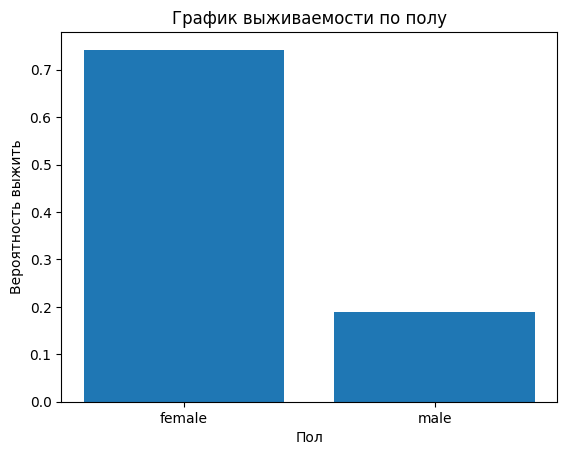

In [18]:
data=df.groupby("Sex")["Survived"].mean()
plt.bar(data.index, data.values)
plt.title("График выживаемости по полу")
plt.xlabel("Пол")
plt.ylabel("Вероятность выжить")
plt.show()

Из графика видно, что выживаемость женщин была намного выше, чем мужчин.

Ниже проверим выживаемость от класса.

In [20]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

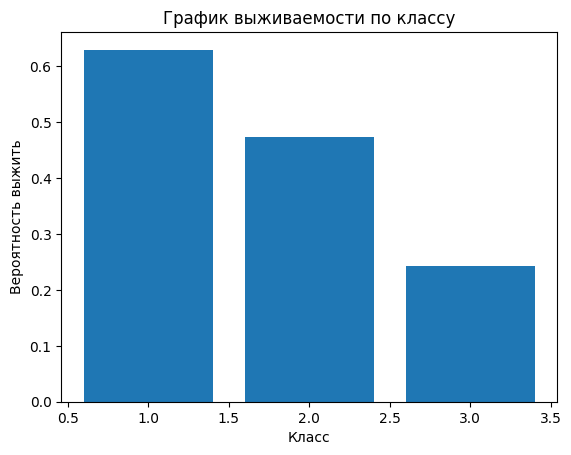

In [19]:
data=df.groupby("Pclass")["Survived"].mean()
plt.bar(data.index, data.values)
plt.title("График выживаемости по классу")
plt.xlabel("Класс")
plt.ylabel("Вероятность выжить")
plt.show()

По графику видно, что выживаемость пассажиров первого класса самая высокая. 2-го класса чуть меньше, 3-го класса совсем небольшая.
Чем выше класс, тем больше шансов выжить.

Ниже проверим выживаемость по полу+классу.

In [21]:
df.groupby(["Sex","Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

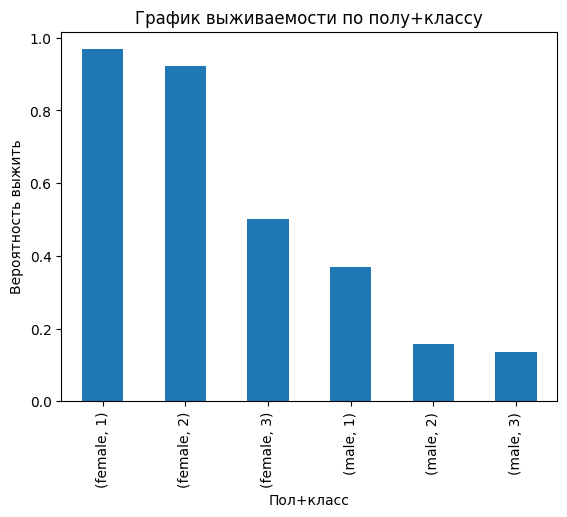

In [22]:
df.groupby(["Sex","Pclass"])["Survived"].mean().plot(kind="bar")
plt.title("График выживаемости по полу+классу")
plt.xlabel("Пол+класс")
plt.ylabel("Вероятность выжить")
plt.show()

Итоговый вывод: выживаемость женщин выше, чем мужчие. Выживаемость первого класса выше, чем в остальных. Выживаемость по полу приоритетнее, чем класс каюты. То есть пол важнее класса: так как выживаемость 2-го класса в среднем 0.47, а женщин 2-го класса 0.92, то есть почти в 2 раза выше.